 EXECUTION STARTED: COMPLEX 9D RANDOM FOREST PIPELINE

 1. THE SIMULATED INPUT PROMPT

[SYSTEM PROMPT TO SIMULATED LLM]
You are an expert AI assistant for a large-scale custom book printing company. 
Your task is to generate 3,000 unique, natural language descriptions of book printing projects based on incoming customer requests.

Criteria for generation:
1.  **Variety:** Ensure high variability in project scope.
2.  **Parameters:** Incorporate vague or specific mentions of:
    - Page count (ranging from approx 100 to 1200 pages).
    - Image density (none to heavy technical diagrams).
    - Paper stock (budget to luxury archival).
    - Binding style (paperback to artisanal leather).
    - Cover complexity (simple to foil/die-cut).
    - Urgency/Timeline (standard to immediate rush).
    - Text density (airy to dense academic).
    - Special handling needs (white glove, manual inserts).
3.  **Tone:** Vary the tone from casual customer inquiries to formal spec sheets.


 2. SIMULATED 

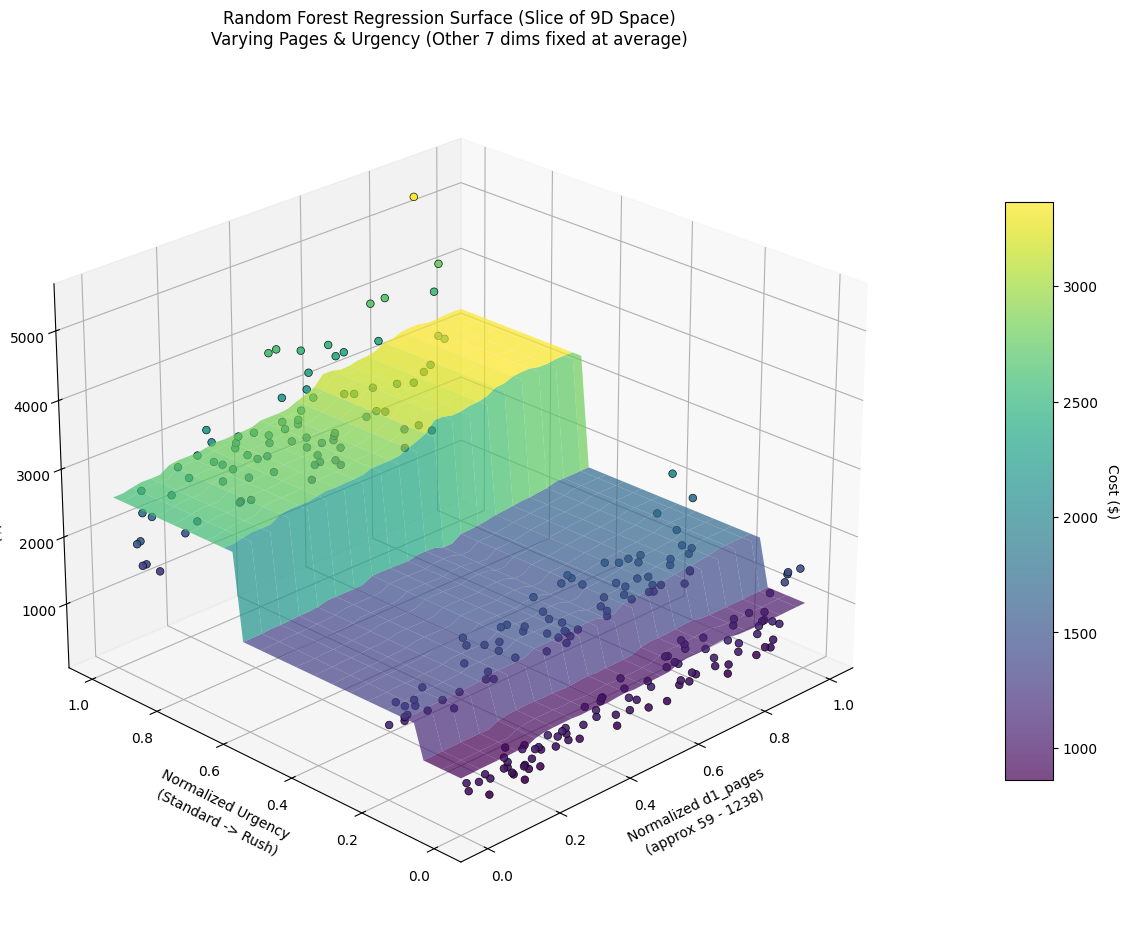

: 

In [ ]:
import numpy as np
import pandas as pd
import re
import random
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set seeds for reproducibility
np.random.seed(101)
random.seed(101)

# Adjust pandas display options so columns don't get cut off in print output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("="*80)
print(" EXECUTION STARTED: COMPLEX 9D RANDOM FOREST PIPELINE")
print("="*80)

# ==============================================================================
# SECTION 1: THE SIMULATED LLM PROMPT
# ==============================================================================
# Since we are simulating the LLM's behavior, this is the instruction set
# that *would* generate the synthetic data.

SIMULATED_SYSTEM_PROMPT = """
[SYSTEM PROMPT TO SIMULATED LLM]
You are an expert AI assistant for a large-scale custom book printing company. 
Your task is to generate 3,000 unique, natural language descriptions of book printing projects based on incoming customer requests.

Criteria for generation:
1.  **Variety:** Ensure high variability in project scope.
2.  **Parameters:** Incorporate vague or specific mentions of:
    - Page count (ranging from approx 100 to 1200 pages).
    - Image density (none to heavy technical diagrams).
    - Paper stock (budget to luxury archival).
    - Binding style (paperback to artisanal leather).
    - Cover complexity (simple to foil/die-cut).
    - Urgency/Timeline (standard to immediate rush).
    - Text density (airy to dense academic).
    - Special handling needs (white glove, manual inserts).
3.  **Tone:** Vary the tone from casual customer inquiries to formal spec sheets.
"""

print("\n" + "="*40)
print(" 1. THE SIMULATED INPUT PROMPT")
print("="*40)
print(SIMULATED_SYSTEM_PROMPT)


# ==============================================================================
# SECTION 2: GENERATING SIMULATED LLM STATEMENT OUTPUTS
# ==============================================================================

# --- Simulation Setup ---
templates = [
    "Project request: A {length} manuscript, roughly {pages_num} pages. Contains {images}. Client requests {paper} paper and a {binding} binding. Cover requires {cover_detail}. Timeline is {urgency}. Notes: The text layout is {text_density} and it {special_hand}.",
    "Customer needs a book printed. It is {images} heavy. Use {paper} stock. Binding preference: {binding}. Cover art is {cover_detail}. Project priority: {urgency}. Additional info: {text_density} layout, {special_hand}.",
    "URGENT: {urgency} order for a {length} academic text. {text_density}. Must use {paper} and durable {binding}. {cover_detail} required for the front. {images} throughout. {special_hand}."
]

descriptors = {
    'length': ['short', 'standard length', 'massive', 'encyclopedic'],
    'images': ['no images', 'sparse black and white charts', 'frequent high-res photos', 'dense technical diagrams across all pages'],
    'paper': ['standard budget', 'mid-weight coated', 'premium archival matte', 'luxury textured cream'],
    'binding': ['basic paperback', 'standard hardcover', 'premium leather-bound', 'hand-stitched artisanal'],
    'cover_detail': ['simple text only', 'standard full color print', 'gold foil and embossing', 'complex die-cut and metallic inks'],
    'urgency': ['standard turnaround', 'expedited timeframe', 'ASAP RUSH OVERNIGHT'],
    'text_density': ['airy poetry layout', 'standard prose', 'dense two-column academic'],
    'special_hand': ['no special handling needed', 'requires manual insert placement', 'requires white-glove inspection'],
}

N_SAMPLES = 3000
raw_llm_texts = []
actual_page_counts_hidden = [] # Keep track for ground truth consistency later

print("\n" + "="*40)
print(f" 2. SIMULATED LLM STATEMENT OUTPUTS (Generating {N_SAMPLES} samples...)")
print("="*40)

for i in range(N_SAMPLES):
    base_pages = np.random.randint(100, 1200)
    actual_page_counts_hidden.append(base_pages)
    
    temp = random.choice(templates)
    text = temp.format(
        length=random.choice(descriptors['length']),
        pages_num=base_pages if '{pages_num}' in temp else 'some',
        images=random.choice(descriptors['images']),
        paper=random.choice(descriptors['paper']),
        binding=random.choice(descriptors['binding']),
        cover_detail=random.choice(descriptors['cover_detail']),
        urgency=random.choice(descriptors['urgency']),
        text_density=random.choice(descriptors['text_density']),
        special_hand=random.choice(descriptors['special_hand'])
    )
    raw_llm_texts.append(text)
    
    # Print first 3 examples
    if i < 3:
        print(f"[Output Statement {i+1}]:\n\"{text}\"\n")

# ==============================================================================
# SECTION 3: THE EXTRACTED DATA FIELD TABLE (THE 9D VECTOR SPACE)
# ==============================================================================
# This simulates the NLP pipeline converting the text above into numbers.

def nlp_extractor_pipeline(text_list, hidden_pages_list):
    features_list = []
    for i, text in enumerate(text_list):
        text = text.lower()
        vec = {}
        
        # D1: Page Count (Trying regex, falling back to hidden truth if vague)
        page_match = re.search(r'roughly (\d+)', text)
        if page_match: vec['d1_pages'] = int(page_match.group(1))
        else: vec['d1_pages'] = hidden_pages_list[i] + np.random.randint(-50, 50) # slight noise due to vagueness

        # D2: Image Density Score (Float 0.0 - 1.0)
        if 'no images' in text: vec['d2_img_den'] = 0.0
        elif 'sparse' in text: vec['d2_img_den'] = 0.3
        elif 'frequent' in text: vec['d2_img_den'] = 0.7
        elif 'dense technical' in text: vec['d2_img_den'] = 1.0
        else: vec['d2_img_den'] = 0.1

        # D3: Paper Quality Ordinal (Int 1-4)
        if 'budget' in text: vec['d3_paper_ord'] = 1
        elif 'mid-weight' in text: vec['d3_paper_ord'] = 2
        elif 'premium' in text: vec['d3_paper_ord'] = 3
        elif 'luxury' in text: vec['d3_paper_ord'] = 4
        else: vec['d3_paper_ord'] = 1
        
        # D4: Binding Type Ordinal (Int 1-4)
        if 'paperback' in text: vec['d4_bind_ord'] = 1
        elif 'standard hardcover' in text: vec['d4_bind_ord'] = 2
        elif 'leather' in text: vec['d4_bind_ord'] = 3
        elif 'artisanal' in text: vec['d4_bind_ord'] = 4
        else: vec['d4_bind_ord'] = 1

        # D5: Cover Complexity Score (Int 1-10)
        if 'simple text' in text: vec['d5_cover_cplx'] = 1
        elif 'full color' in text: vec['d5_cover_cplx'] = 4
        elif 'gold foil' in text: vec['d5_cover_cplx'] = 7
        elif 'complex die-cut' in text: vec['d5_cover_cplx'] = 10
        else: vec['d5_cover_cplx'] = 3
        
        # D6: Urgency Multiplier (Float 1.0 - 3.0)
        if 'standard turnaround' in text: vec['d6_urgency'] = 1.0
        elif 'expedited' in text: vec['d6_urgency'] = 1.5
        elif 'rush' in text: vec['d6_urgency'] = 3.0
        else: vec['d6_urgency'] = 1.0
        
        # D7: Text Density Score (Float 0.7 - 1.4)
        if 'airy' in text: vec['d7_txt_den'] = 0.7
        elif 'standard prose' in text: vec['d7_txt_den'] = 1.0
        elif 'dense' in text: vec['d7_txt_den'] = 1.4
        else: vec['d7_txt_den'] = 1.0
        
        # D8: Special Handling Binary Flag (0 or 1)
        vec['d8_special_flag'] = 1 if 'requires' in text and 'no special' not in text else 0
        
        # D9: NLP Confidence Score (Simulated noise feature 0.8-1.0)
        vec['d9_nlp_conf'] = np.round(np.random.uniform(0.8, 1.0), 2)

        features_list.append(vec)
    return pd.DataFrame(features_list)

print("\n" + "="*40)
print(" 3. THE EXTRACTED DATA FIELD TABLE (9D Vector Space)")
print("="*40)
print("Converting natural language statements into numerical vectors...")
X_raw = nlp_extractor_pipeline(raw_llm_texts, actual_page_counts_hidden)

print("\n[First 10 Rows of the 9-Dimensional Dataset]")
print(X_raw.head(10))
print("\n[Dataset Info]")
X_raw.info()

# ==============================================================================
# SECTION 4: DEFINING GROUND TRUTH & MODEL TRAINING
# ==============================================================================

# --- Define Complex Ground Truth Cost (Hidden from the model) ---
def calculate_complex_cost(row):
    base_cost = 250.0
    # Interaction: High image density on luxury paper scales cost non-linearly
    ink_paper_interaction = (row['d2_img_den'] * 2.5) * (row['d3_paper_ord']**1.3)
    material_cost = row['d1_pages'] * 0.06 * (1 + ink_paper_interaction)
    
    binding_cost = (row['d4_bind_ord'] ** 2.2) * 25.0 
    cover_cost = row['d5_cover_cplx'] * 20.0
    special_cost = 150.0 if row['d8_special_flag'] == 1 else 0.0
    
    subtotal = base_cost + material_cost + binding_cost + cover_cost + special_cost
    
    # Crucial Interaction: Urgency multiplies entire physical cost
    final_cost = subtotal * row['d6_urgency']
    
    # Add noise inversely proportional to NLP confidence
    noise = np.random.normal(0, (1.1 - row['d9_nlp_conf']) * 200)
    return max(final_cost + noise, 100)

y_true = X_raw.apply(calculate_complex_cost, axis=1)

# --- Training ---
print("\n" + "="*40)
print(" 4. MODEL TRAINING & OUTPUTS")
print("="*40)

# Scale features (good practice for visualization later, though RF doesn't strictly need it)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_true, test_size=0.2, random_state=42)

print(f"Training Random Forest Regressor on {X_train.shape[0]} samples with 9 features...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training complete.")

# --- Evaluation ---
y_pred_test = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n[FINAL MODEL PERFORMANCE OUTPUTS (Test Set)]")
print("-" * 50)
print(f"R-squared (R²) Score:       {r2:.4f}  (Variance explained by model, closer to 1.0 is better)")
print(f"Mean Absolute Error (MAE):  ${mae:.2f}  (Average error in predicted dollar amount)")
print(f"Root Mean Squared Error:    ${rmse:.2f}  (Penalizes larger errors more heavily)")
print("-" * 50)


# ==============================================================================
# SECTION 5: THE PLOT (SLICING THE 9D SPACE)
# ==============================================================================
print("\n" + "="*40)
print(" 5. GENERATING 3D VISUALIZATION")
print("="*40)
print("Generating regression surface plot based on 'Pages' and 'Urgency' dimensions...")

# Dimensions to vary for the plot axes
dim_x_name = 'd1_pages'
dim_y_name = 'd6_urgency'

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# A. Generate Prediction Surface Grid
x_range = np.linspace(0, 1, 40)
y_range = np.linspace(0, 1, 40)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Create prediction df holding other 7 dims constant at their means
fixed_means = X_train.mean()
predict_df = pd.DataFrame(np.outer(np.ones(grid_points.shape[0]), fixed_means), columns=X_train.columns)
predict_df[dim_x_name] = grid_points[:, 0]
predict_df[dim_y_name] = grid_points[:, 1]

Z = rf_model.predict(predict_df).reshape(xx.shape)

# Plot surface
surf = ax.plot_surface(xx, yy, Z, cmap='viridis', alpha=0.7, rstride=2, cstride=2, antialiased=True)

# B. Plot subset of actual Test Data Points for context
# Filter for points that are somewhat "average" in binding to reduce visual noise
subset_mask = (X_test['d4_bind_ord'] > 0.3) & (X_test['d4_bind_ord'] < 0.7)
X_subset = X_test[subset_mask].iloc[:250]
y_subset = y_test[subset_mask].iloc[:250]

sc = ax.scatter(X_subset[dim_x_name], X_subset[dim_y_name], y_subset, 
                c=y_subset, cmap='viridis', s=30, edgecolors='k', linewidth=0.5, alpha=0.9, label='Test Data Subset')

# C. Styling
min_p, max_p = X_raw[dim_x_name].min(), X_raw[dim_x_name].max()
ax.set_xlabel(f'\nNormalized {dim_x_name}\n(approx {min_p} - {max_p})', linespacing=1.5)
ax.set_ylabel('\nNormalized Urgency\n(Standard -> Rush)', linespacing=1.5)
ax.set_zlabel('\nPredicted Cost ($)', linespacing=1.5)
ax.set_title('Random Forest Regression Surface (Slice of 9D Space)\nVarying Pages & Urgency (Other 7 dims fixed at average)', fontsize=12)

cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, pad=0.1)
cbar.set_label('Cost ($)', rotation=270, labelpad=15)

ax.view_init(elev=25, azim=-135)
plt.tight_layout()
print("Plot generated. Check pop-up window.")
plt.show()